In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [72]:
class SimpleLinearModel:
    def __init__(self,input_dim):
        self.w=np.random.rand(input_dim,1)*(np.sqrt(2.0/input_dim))
        self.b=np.zeros((1,1))

    def forward(self,x_train):
        return np.dot(x_train,self.w)+self.b

    def compute_gradient(self,x,y,y_hat):
        m=x.shape[0]
        error=y_hat-y
        dw=(1/m)*np.dot(x.T,error)
        db=(1/m)*np.sum(error,axis=0,keepdims=True)

        return dw ,db

    def update_gradient(self,dw,db,lr):
        self.w-=lr*dw
        self.b-=lr*db
        

In [99]:
def LR_finder(model,x_data,y_data,batch_size=32,start_lr=1e-6,end_lr=10.0,num_iter=100):
    lr_hist=[]
    loss_hist=[]

    q=(end_lr/start_lr)**(1/num_iter)
    current_lr=start_lr

    num_sample=x_data.shape[0]
    running_loss=0.0
    best_loss = float("inf")

    for i in range(num_iter):
        indeices=np.random.choice(num_sample,batch_size,replace=False)
        x_batch=x_data[indeices]
        y_batch=y_data[indeices]


        y_hat=model.forward(x_batch)

        loss=0.5*np.mean((y_hat-y_batch)**2)

        #avoid chatstrohic gradient exploding
        if np.isnan(loss) or (i>0 and loss>loss_hist[0]*5):
            print(f"Loss exploded at iteration {i} (LR :{current_lr:.5f} stopping test")
            break

        dw,db=model.compute_gradient(x_batch,y_batch,y_hat)

        model.update_gradient(dw,db,current_lr)

        best_loss = min(best_loss, running_loss)

        if running_loss > best_loss * 5:
            break


        lr_hist.append(current_lr)
        loss_hist.append(running_loss)

        current_lr *=q
    return lr_hist,loss_hist
        
    

In [100]:
def plot_lr(lr_hist,loss_hist):
    plt.figure(figsize=(10,8))
    plt.semilogx(lr_hist,loss_hist)
    plt.xlabel("Log sclae(LR)")
    plt.ylabel("Loss")
    plt.title("LR range test")
    plt.grid(True,which='both',linestyle='--')
    plt.show()

In [101]:
class LRSheduler:
    @staticmethod
    def decay(initial_lr,epoch,step_size=20,gamma=0.1):
        return initial_lr * (gamma**(epoch//step_size))

    @staticmethod
    def cosine_anealing(initial_lr,epoch,t_max=20,lr_min=1e-6):
        cosine=(1+np.cos(np.pi*epoch/t_max))
        return lr_min+0.5*(initial_lr-lr_min)*cosine

In [102]:
x=np.random.rand(1000,4)*10
true_w=np.array([1.0,0.9,0.0,5])

y=(np.dot(x,true_w)+np.random.randn(1000) * 0.5).reshape(-1,1)

In [103]:
x.shape

(1000, 4)

In [104]:
y.shape

(1000, 1)

In [105]:
model=SimpleLinearModel(input_dim=4)

In [106]:
lr_hist,loss_hist=LR_finder(model,x,y)

Loss exploded at iteration 1 (LR :0.00000 stopping test


In [107]:
lr_hist

[1e-06]

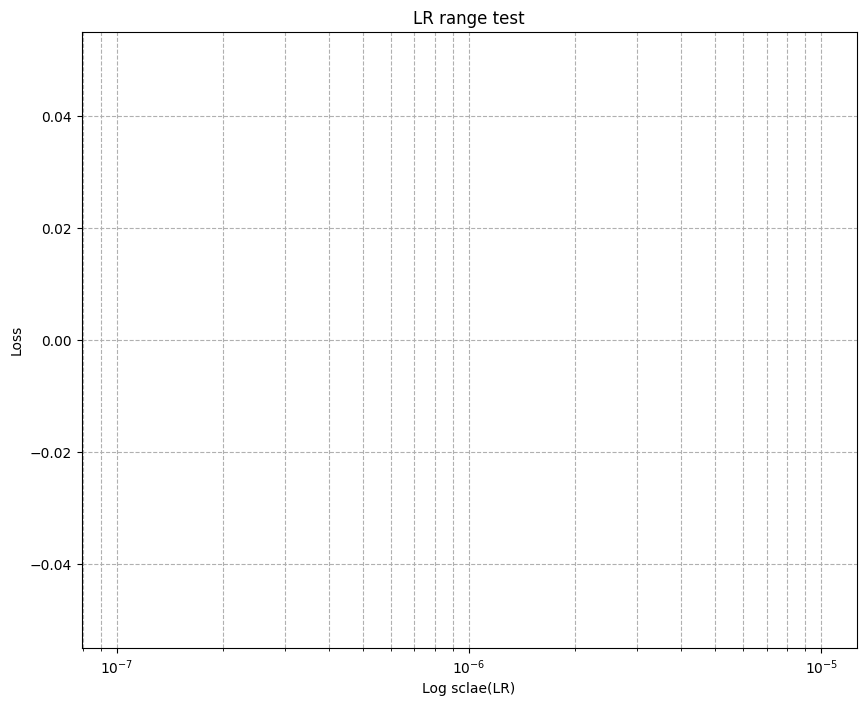

In [108]:
plot_lr(lr_hist,loss_hist)

In [109]:
lr_shedular=LRSheduler()

In [110]:
inittial_lr=10**-4
epoch=100
lr_shedular.decay(inittial_lr,epoch,gamma=0.5)

3.125e-06

In [111]:
lr_shedular.cosine_anealing(inittial_lr,epoch)

1e-06

In [40]:
0.0000006==1e-06

False

In [41]:
1e-06

1e-06